# Adversarial Attack Sensitivity Study 

By systematically varying various hyperparameters relevant to adversarial attacks, such as epsilon (eps) values in methods like the Fast Gradient Sign Method (FGSM). This exploration helps understand the interplay between different hyperparameters and the model's susceptibility to adversarial examples, contributing to the development of robust defense strategies and insights into the model's resilience against adversarial attacks.

## Importing our data  

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, recall_score, precision_score, f1_score
from math import sqrt
import os
import csv

# Load the dataset
file_path = '/work/Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

# Placeholder for dataset preprocessing
#target = 'your_target_column'
#features = data.drop(target, axis=1)

from sklearn.preprocessing import LabelEncoder

# Encoding the target variable
label_encoder = LabelEncoder()
data['prognosis_encoded'] = label_encoder.fit_transform(data['prognosis'])

# Separating features and target variable
#X = data.drop(['id', 'prognosis', 'prognosis_encoded'], axis=1)
X = data.drop(['prognosis', 'prognosis_encoded'], axis=1)

y = data['prognosis_encoded']



# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=29)

# PGD with XGboost

/root/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:09:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


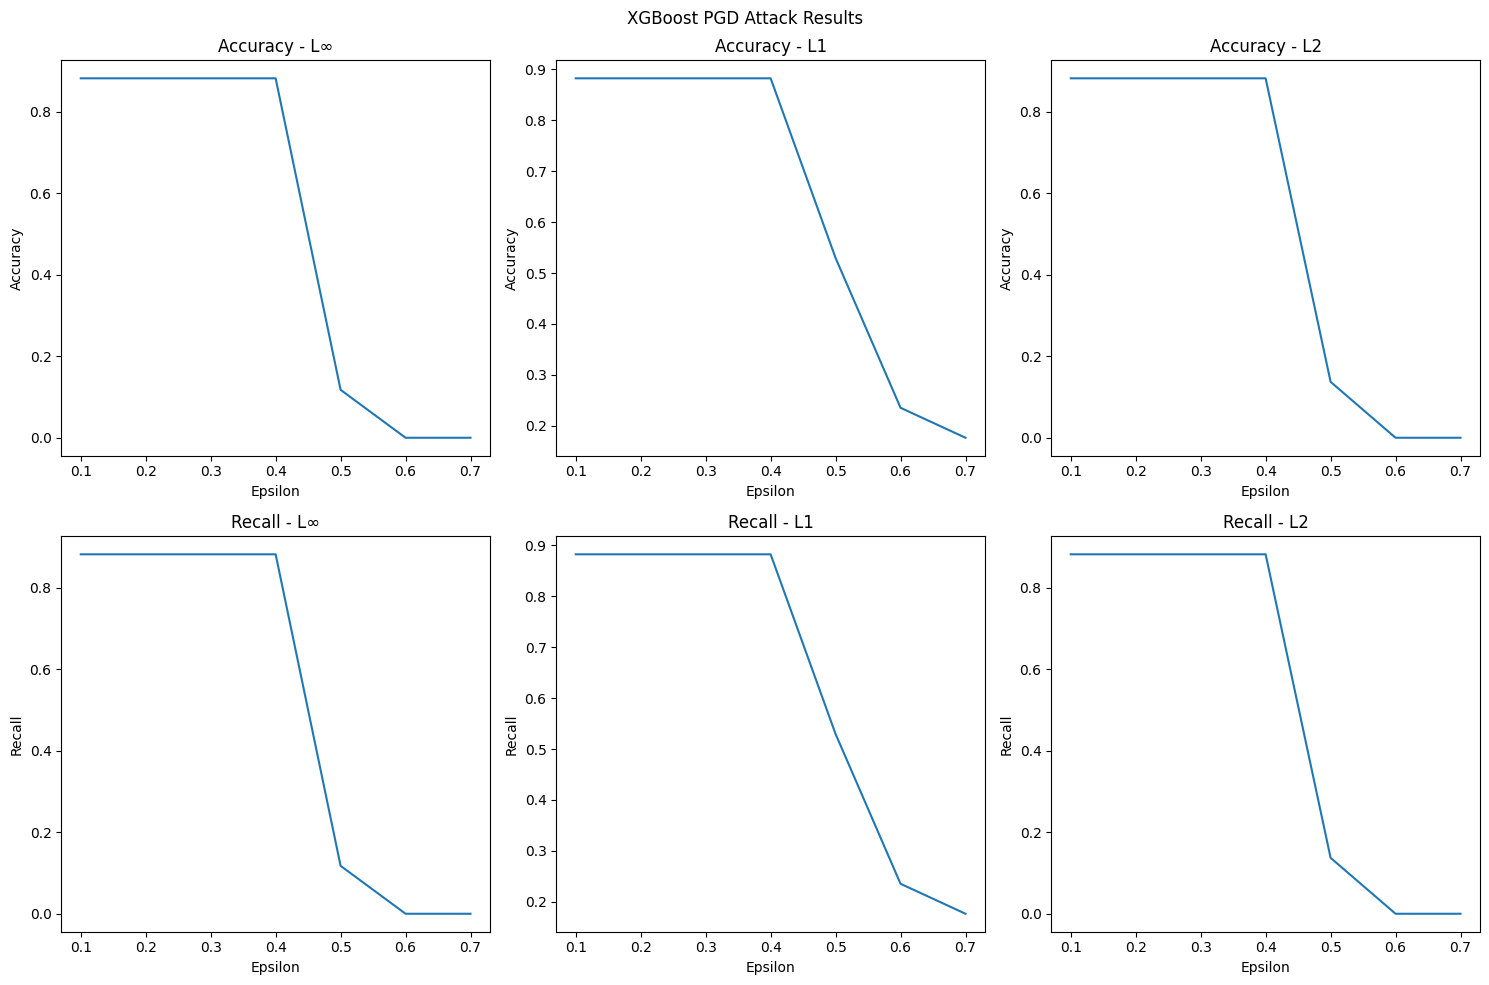


Results for L∞ norm:
Epsilon	Accuracy	Recall
0.10	0.8824		0.8824
0.20	0.8824		0.8824
0.30	0.8824		0.8824
0.40	0.8824		0.8824
0.50	0.1176		0.1176
0.60	0.0000		0.0000
0.70	0.0000		0.0000

Results for L1 norm:
Epsilon	Accuracy	Recall
0.10	0.8824		0.8824
0.20	0.8824		0.8824
0.30	0.8824		0.8824
0.40	0.8824		0.8824
0.50	0.5294		0.5294
0.60	0.2353		0.2353
0.70	0.1765		0.1765

Results for L2 norm:
Epsilon	Accuracy	Recall
0.10	0.8824		0.8824
0.20	0.8824		0.8824
0.30	0.8824		0.8824
0.40	0.8824		0.8824
0.50	0.1373		0.1373
0.60	0.0000		0.0000
0.70	0.0000		0.0000


In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, recall_score
import matplotlib.pyplot as plt

# Load and preprocess the data
file_path = '/work/Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Train XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)

# Function to compute numerical gradient
def compute_gradient(model, X, y):
    gradient = np.zeros_like(X, dtype=float)
    for i in range(X.shape[1]):
        X_plus = X.copy()
        X_plus[:, i] = np.minimum(X_plus[:, i] + 1, 1)  # Increase by 1, but not exceeding 1
        X_minus = X.copy()
        X_minus[:, i] = np.maximum(X_minus[:, i] - 1, 0)  # Decrease by 1, but not below 0
        
        loss_plus = -np.log(model.predict_proba(X_plus)[np.arange(len(y)), y])
        loss_minus = -np.log(model.predict_proba(X_minus)[np.arange(len(y)), y])
        
        gradient[:, i] = loss_plus - loss_minus
    return gradient

# PGD attack function
def pgd_attack(model, X, y, eps, num_steps, norm):
    X_adv = X.copy().astype(float)
    X_nat = X.copy().astype(float)
    for _ in range(num_steps):
        gradient = compute_gradient(model, X_adv.astype(int), y)
        if norm == np.inf:
            perturbation = np.sign(gradient)
        elif norm == 1:
            perturbation = gradient / np.sum(np.abs(gradient), axis=1, keepdims=True)
        elif norm == 2:
            perturbation = gradient / np.linalg.norm(gradient, axis=1, keepdims=True)
        
        X_adv += eps * perturbation
        X_adv = np.clip(X_adv, X_nat - eps, X_nat + eps)
        X_adv = np.clip(X_adv, 0, 1)
    
    return np.round(X_adv).astype(int)  # Round to nearest integer

# Perform attacks and evaluate
norms = [np.inf, 1, 2]
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
num_steps = 10

results = {norm: {'accuracy': [], 'recall': []} for norm in norms}

for norm in norms:
    for eps in eps_values:
        X_adv = pgd_attack(model, X_test.values, y_test, eps, num_steps, norm)
        y_pred = model.predict(X_adv)
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred, average='weighted')
        results[norm]['accuracy'].append(accuracy)
        results[norm]['recall'].append(recall)

# Plot results
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('XGBoost PGD Attack Results')

for i, norm in enumerate(norms):
    axs[0, i].plot(eps_values, results[norm]['accuracy'])
    axs[0, i].set_title(f'Accuracy - L{norm if norm != np.inf else "∞"}')
    axs[0, i].set_xlabel('Epsilon')
    axs[0, i].set_ylabel('Accuracy')

    axs[1, i].plot(eps_values, results[norm]['recall'])
    axs[1, i].set_title(f'Recall - L{norm if norm != np.inf else "∞"}')
    axs[1, i].set_xlabel('Epsilon')
    axs[1, i].set_ylabel('Recall')

plt.tight_layout()
plt.show()

# Print results
for norm in norms:
    print(f"\nResults for L{norm if norm != np.inf else '∞'} norm:")
    print("Epsilon\tAccuracy\tRecall")
    for eps, acc, rec in zip(eps_values, results[norm]['accuracy'], results[norm]['recall']):
        print(f"{eps:.2f}\t{acc:.4f}\t\t{rec:.4f}")

### ANN PGD Attack Implementation

2/2 [==============================] - 0s 2ms/step


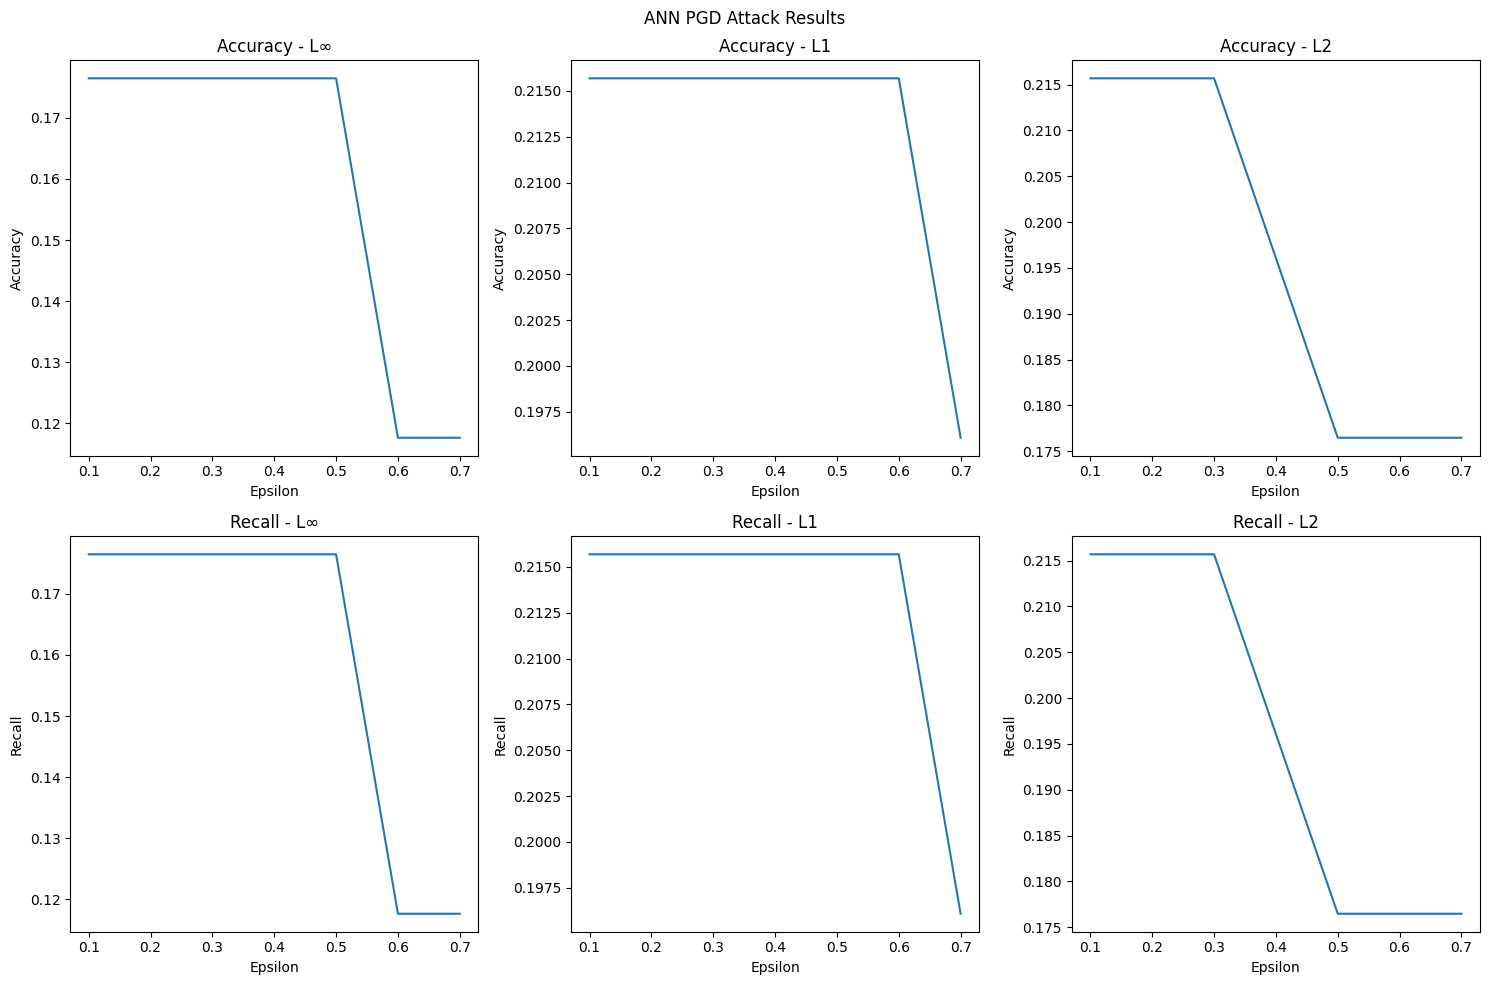


Results for L∞ norm:
Epsilon	Accuracy	Recall
0.10	0.1765		0.1765
0.20	0.1765		0.1765
0.30	0.1765		0.1765
0.40	0.1765		0.1765
0.50	0.1765		0.1765
0.60	0.1176		0.1176
0.70	0.1176		0.1176

Results for L1 norm:
Epsilon	Accuracy	Recall
0.10	0.2157		0.2157
0.20	0.2157		0.2157
0.30	0.2157		0.2157
0.40	0.2157		0.2157
0.50	0.2157		0.2157
0.60	0.2157		0.2157
0.70	0.1961		0.1961

Results for L2 norm:
Epsilon	Accuracy	Recall
0.10	0.2157		0.2157
0.20	0.2157		0.2157
0.30	0.2157		0.2157
0.40	0.1961		0.1961
0.50	0.1765		0.1765
0.60	0.1765		0.1765
0.70	0.1765		0.1765


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score
import matplotlib.pyplot as plt

# Load and preprocess the data
file_path = '/work/Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to float32 for TensorFlow
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

# Build the ANN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])


model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# PGD attack function
@tf.function
def pgd_attack(model, x, y, epsilon, alpha, num_iter, norm):
    x_adv = tf.identity(x)
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy()
    
    for _ in range(num_iter):
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            prediction = model(x_adv)
            loss = loss_object(y, prediction)
        gradient = tape.gradient(loss, x_adv)
        
        if norm == np.inf:
            signed_grad = tf.sign(gradient)
            x_adv = x_adv + alpha * signed_grad
        elif norm == 1:
            grad_norm = tf.norm(gradient, ord=1, axis=1, keepdims=True)
            normalized_grad = gradient / grad_norm
            x_adv = x_adv + alpha * normalized_grad
        elif norm == 2:
            grad_norm = tf.norm(gradient, ord=2, axis=1, keepdims=True)
            normalized_grad = gradient / grad_norm
            x_adv = x_adv + alpha * normalized_grad
        
        x_adv = tf.clip_by_value(x_adv, x - epsilon, x + epsilon)
        x_adv = tf.clip_by_value(x_adv, 0, 1)
    
    return x_adv

# Perform attacks and evaluate
norms = [np.inf, 1, 2]
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
alpha = 0.01
num_iter = 10

results = {norm: {'accuracy': [], 'recall': []} for norm in norms}

for norm in norms:
    for eps in eps_values:
        X_adv = pgd_attack(model, X_test_scaled, y_test, eps, alpha, num_iter, norm)
        y_pred = np.argmax(model.predict(X_adv), axis=1)
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred, average='weighted')
        results[norm]['accuracy'].append(accuracy)
        results[norm]['recall'].append(recall)

# Plot results
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('ANN PGD Attack Results')

for i, norm in enumerate(norms):
    axs[0, i].plot(eps_values, results[norm]['accuracy'])
    axs[0, i].set_title(f'Accuracy - L{norm if norm != np.inf else "∞"}')
    axs[0, i].set_xlabel('Epsilon')
    axs[0, i].set_ylabel('Accuracy')

    axs[1, i].plot(eps_values, results[norm]['recall'])
    axs[1, i].set_title(f'Recall - L{norm if norm != np.inf else "∞"}')
    axs[1, i].set_xlabel('Epsilon')
    axs[1, i].set_ylabel('Recall')

plt.tight_layout()
plt.show()

# Print results
for norm in norms:
    print(f"\nResults for L{norm if norm != np.inf else '∞'} norm:")
    print("Epsilon\tAccuracy\tRecall")
    for eps, acc, rec in zip(eps_values, results[norm]['accuracy'], results[norm]['recall']):
        print(f"{eps:.2f}\t{acc:.4f}\t\t{rec:.4f}")

# FGSM (Fast-Gradient Sign Method)

Hyperparameters:

estimator – A trained classifier.

norm – The norm of the adversarial perturbation. Possible values: “inf”, np.inf, 1 or 2.

eps – Attack step size (input variation).

eps_step – Step size of input variation for minimal perturbation computation.

2024-07-31 10:03:47.085107: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-31 10:03:47.199979: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-07-31 10:03:47.200004: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2024-07-31 10:03:47.225107: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-31 10:03:47.860765: W tensorflow/stream_executor/platform/de

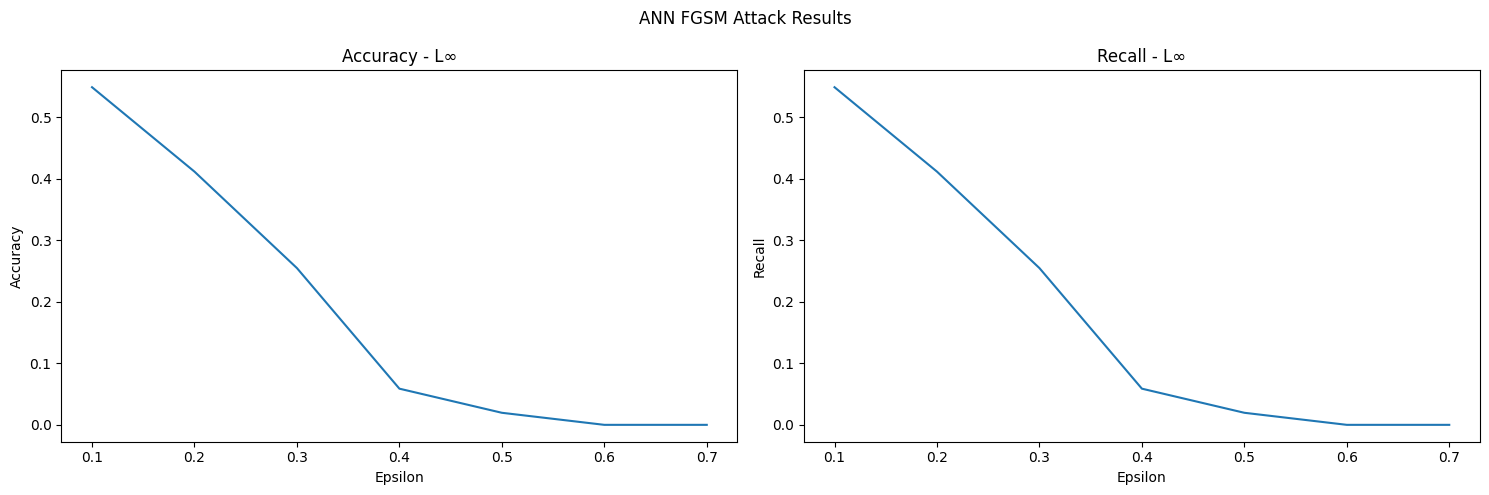


Results for L∞ norm:
Epsilon	Accuracy	Recall
0.10	0.5490		0.5490
0.20	0.4118		0.4118
0.30	0.2549		0.2549
0.40	0.0588		0.0588
0.50	0.0196		0.0196
0.60	0.0000		0.0000
0.70	0.0000		0.0000


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score
import matplotlib.pyplot as plt

# Load and preprocess the data
file_path = '/work/Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to float32 for TensorFlow
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

# Build the ANN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# FGSM attack function
@tf.function
def fgsm_attack(model, x, y, epsilon):
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy()
    with tf.GradientTape() as tape:
        tape.watch(x)
        prediction = model(x)
        loss = loss_object(y, prediction)
    gradient = tape.gradient(loss, x)
    signed_grad = tf.sign(gradient)
    return x + epsilon * signed_grad

# Perform attacks and evaluate
norms = [np.inf]  # FGSM typically uses L-inf norm
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = {norm: {'accuracy': [], 'recall': []} for norm in norms}

for norm in norms:
    for eps in eps_values:
        X_adv = fgsm_attack(model, X_test_scaled, y_test, eps)
        y_pred = np.argmax(model.predict(X_adv), axis=1)
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred, average='weighted')
        results[norm]['accuracy'].append(accuracy)
        results[norm]['recall'].append(recall)

# Plot results
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ANN FGSM Attack Results')

axs[0].plot(eps_values, results[np.inf]['accuracy'])
axs[0].set_title('Accuracy - L∞')
axs[0].set_xlabel('Epsilon')
axs[0].set_ylabel('Accuracy')

axs[1].plot(eps_values, results[np.inf]['recall'])
axs[1].set_title('Recall - L∞')
axs[1].set_xlabel('Epsilon')
axs[1].set_ylabel('Recall')

plt.tight_layout()
plt.show()

# Print results
print(f"\nResults for L∞ norm:")
print("Epsilon\tAccuracy\tRecall")
for eps, acc, rec in zip(eps_values, results[np.inf]['accuracy'], results[np.inf]['recall']):
    print(f"{eps:.2f}\t{acc:.4f}\t\t{rec:.4f}")

2/2 [==============================] - 0s 2ms/step


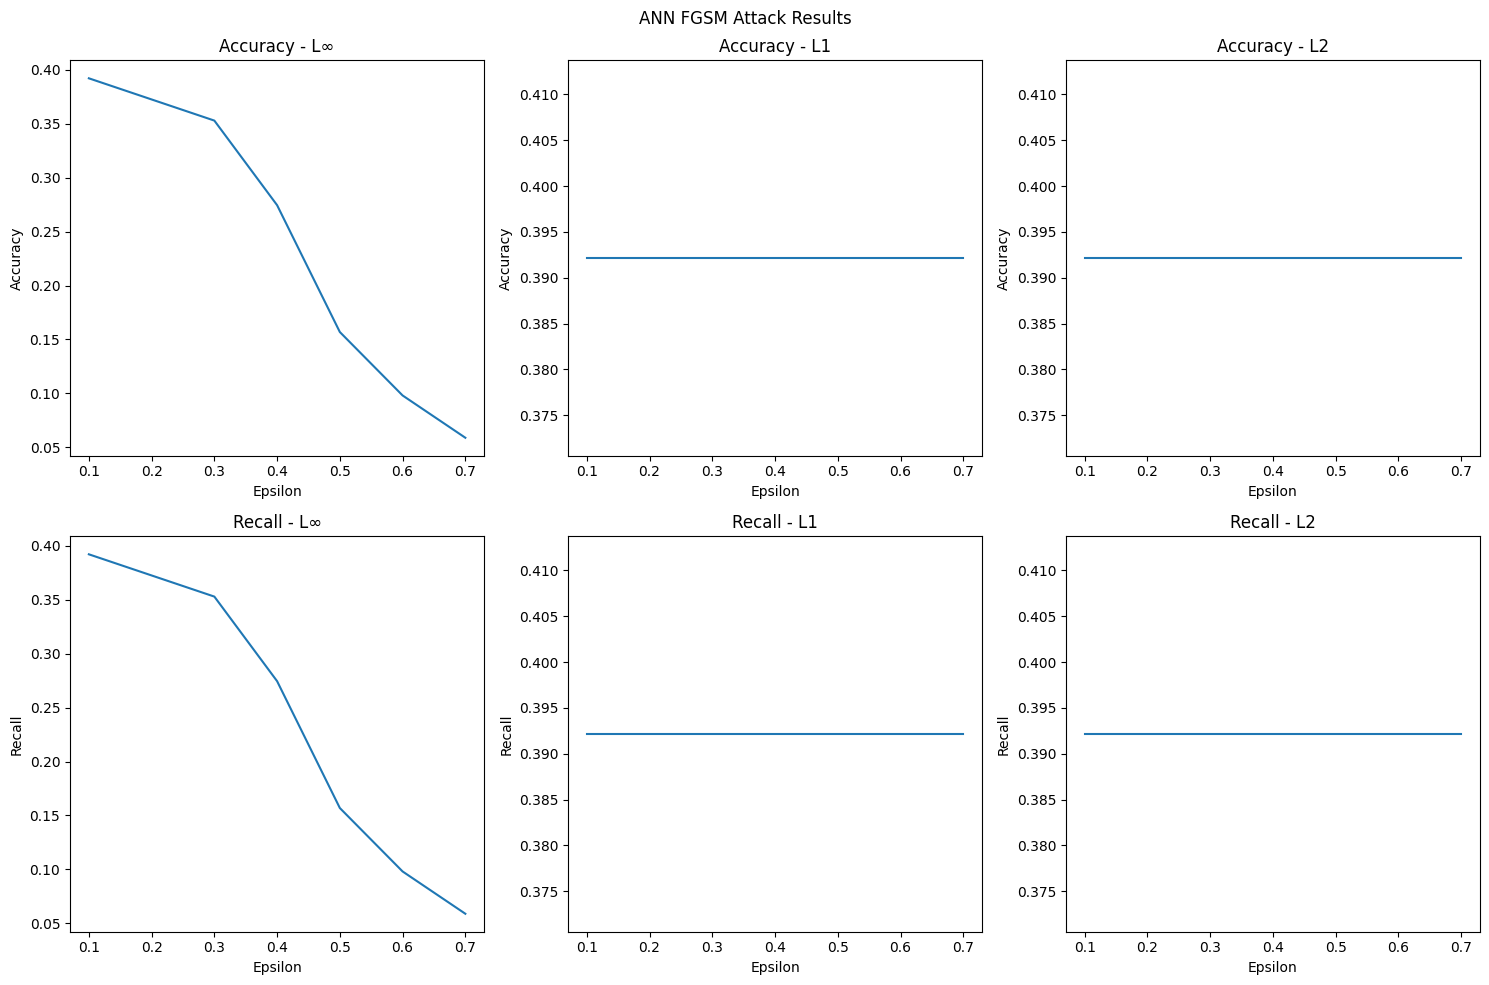


Results for L∞ norm:
Epsilon	Accuracy	Recall
0.10	0.3922		0.3922
0.20	0.3725		0.3725
0.30	0.3529		0.3529
0.40	0.2745		0.2745
0.50	0.1569		0.1569
0.60	0.0980		0.0980
0.70	0.0588		0.0588

Results for L1 norm:
Epsilon	Accuracy	Recall
0.10	0.3922		0.3922
0.20	0.3922		0.3922
0.30	0.3922		0.3922
0.40	0.3922		0.3922
0.50	0.3922		0.3922
0.60	0.3922		0.3922
0.70	0.3922		0.3922

Results for L2 norm:
Epsilon	Accuracy	Recall
0.10	0.3922		0.3922
0.20	0.3922		0.3922
0.30	0.3922		0.3922
0.40	0.3922		0.3922
0.50	0.3922		0.3922
0.60	0.3922		0.3922
0.70	0.3922		0.3922


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score
import matplotlib.pyplot as plt

# Load and preprocess the data
file_path = '/work/Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to float32 for TensorFlow
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

# Build the ANN model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# FGSM attack function
@tf.function
def fgsm_attack(model, x, y, epsilon, norm):
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy()
    with tf.GradientTape() as tape:
        tape.watch(x)
        prediction = model(x)
        loss = loss_object(y, prediction)
    gradient = tape.gradient(loss, x)
    
    if norm == np.inf:
        perturbation = epsilon * tf.sign(gradient)
    elif norm == 1:
        perturbation = epsilon * tf.math.divide_no_nan(gradient, tf.norm(gradient, ord=1, axis=1, keepdims=True))
    elif norm == 2:
        perturbation = epsilon * tf.math.divide_no_nan(gradient, tf.norm(gradient, ord=2, axis=1, keepdims=True))
    
    return tf.clip_by_value(x + perturbation, 0, 1)

# Perform attacks and evaluate
norms = [np.inf, 1, 2]
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = {norm: {'accuracy': [], 'recall': []} for norm in norms}

for norm in norms:
    for eps in eps_values:
        X_adv = fgsm_attack(model, X_test_scaled, y_test, eps, norm)
        y_pred = np.argmax(model.predict(X_adv), axis=1)
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred, average='weighted')
        results[norm]['accuracy'].append(accuracy)
        results[norm]['recall'].append(recall)

# Plot results
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('ANN FGSM Attack Results')

for i, norm in enumerate(norms):
    axs[0, i].plot(eps_values, results[norm]['accuracy'])
    axs[0, i].set_title(f'Accuracy - L{norm if norm != np.inf else "∞"}')
    axs[0, i].set_xlabel('Epsilon')
    axs[0, i].set_ylabel('Accuracy')

    axs[1, i].plot(eps_values, results[norm]['recall'])
    axs[1, i].set_title(f'Recall - L{norm if norm != np.inf else "∞"}')
    axs[1, i].set_xlabel('Epsilon')
    axs[1, i].set_ylabel('Recall')

plt.tight_layout()
plt.show()

# Print results
for norm in norms:
    print(f"\nResults for L{norm if norm != np.inf else '∞'} norm:")
    print("Epsilon\tAccuracy\tRecall")
    for eps, acc, rec in zip(eps_values, results[norm]['accuracy'], results[norm]['recall']):
        print(f"{eps:.2f}\t{acc:.4f}\t\t{rec:.4f}")

### Norm: L-infinity

/shared-libs/python3.9/py/lib/python3.9/site-packages/keras/engine/training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


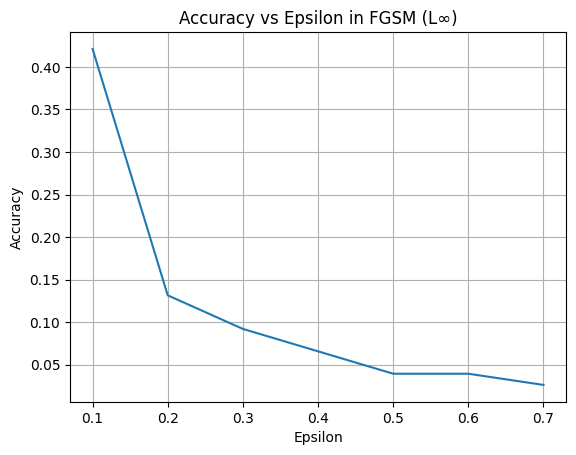

In [ ]:
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod,ProjectedGradientDescent,BoundaryAttack
from art.estimators.classification import SklearnClassifier,KerasClassifier
from art.utils import to_categorical
from sklearn.metrics import recall_score
tf.compat.v1.disable_eager_execution()
ann = tf.keras.models.load_model('/work/models/best_ann_model.h5')

print(ann)
# Create an ART classifier object wrapping the loaded model
classifier = KerasClassifier(ann)

# Create the FGSM attack object
fgsm = FastGradientMethod(classifier,targeted=False)

eps_values = [0.1, 0.2, 0.3,0.4,0.5,0.6,0.7]  # Example epsilon values
#eps_values  = [0.1,0.12,0.14,0.16,0.18,0.2]
eps_size_values = [1, 2, 3]    # Example epsilon size values
norm_values = [np.inf] 

results = []

for eps in eps_values:
    for eps_size in eps_size_values:
        for norm in norm_values:
            # Create the FGSM attack|
            attack = FastGradientMethod(classifier, eps=eps, eps_step=eps_size, norm=norm)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (e.g., accuracy) and store the results
            accuracy = np.sum(y_test_adv_pred == y_test) / len(y_test)
            results.append((eps, eps_size, norm, accuracy))

# Step 5: Plot the results
eps_values = [result[0] for result in results]
accuracy_values = [result[3] for result in results]

plt.plot(eps_values, accuracy_values)
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon in FGSM (L∞)')
plt.grid(True)
plt.show()

/shared-libs/python3.9/py/lib/python3.9/site-packages/keras/engine/training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


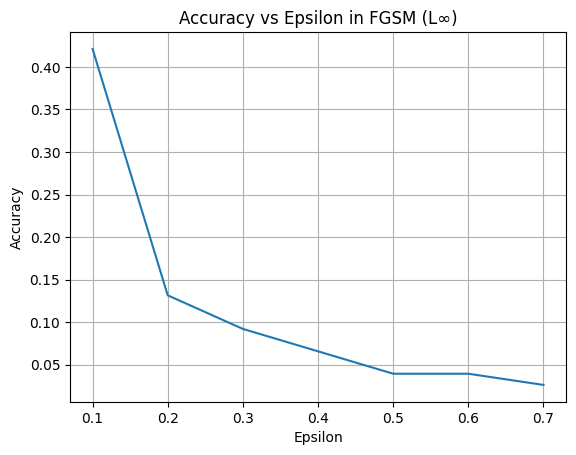

In [ ]:
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod,ProjectedGradientDescent,BoundaryAttack
from art.estimators.classification import SklearnClassifier,KerasClassifier
from art.utils import to_categorical
from sklearn.metrics import recall_score
tf.compat.v1.disable_eager_execution()
ann = tf.keras.models.load_model('/work/models/best_ann_model.h5')

print(ann)
# Create an ART classifier object wrapping the loaded model
classifier = KerasClassifier(ann)

# Create the FGSM attack object
fgsm = FastGradientMethod(classifier,targeted=False)

eps_values = [0.1, 0.2, 0.3,0.4,0.5,0.6,0.7]  # Example epsilon values
#eps_values  = [0.1,0.12,0.14,0.16,0.18,0.2]
eps_size_values = [1, 2, 3]    # Example epsilon size values
norm_values = [np.inf] 

results = []

for eps in eps_values:
    for eps_size in eps_size_values:
        for norm in norm_values:
            # Create the FGSM attack
            attack = FastGradientMethod(classifier, eps=eps, eps_step=eps_size, norm=norm)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (e.g., accuracy) and store the results
            accuracy = np.sum(y_test_adv_pred == y_test) / len(y_test)
            results.append((eps, eps_size, norm, accuracy))

# Step 5: Plot the results
eps_values = [result[0] for result in results]
accuracy_values = [result[3] for result in results]

plt.plot(eps_values, accuracy_values)
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.grid(True)
plt.title('Accuracy vs Epsilon in FGSM (L∞)')
plt.show()

/shared-libs/python3.9/py/lib/python3.9/site-packages/keras/engine/training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


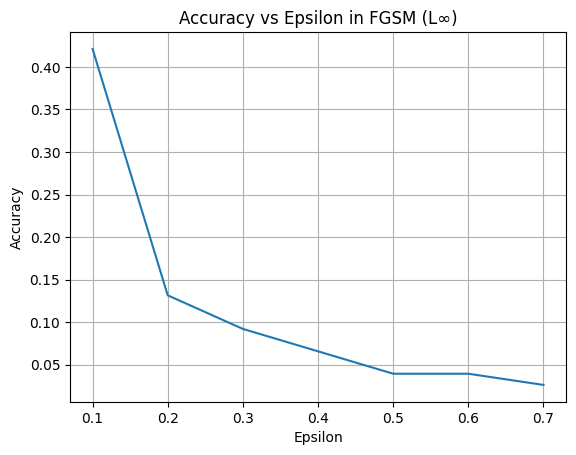

In [ ]:
import joblib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod,ProjectedGradientDescent,BoundaryAttack
from art.estimators.classification import SklearnClassifier,KerasClassifier
from art.utils import to_categorical
from sklearn.metrics import recall_score
tf.compat.v1.disable_eager_execution()
ann = tf.keras.models.load_model('/work/models/best_ann_model.h5')

print(ann)
# Create an ART classifier object wrapping the loaded model
classifier = KerasClassifier(ann)

# Create the FGSM attack object
fgsm = FastGradientMethod(classifier,targeted=False)

eps_values = [0.1, 0.2, 0.3,0.4,0.5,0.6,0.7]  # Example epsilon values
#eps_values  = [0.1,0.12,0.14,0.16,0.18,0.2]
eps_size_values = [1, 2, 3]    # Example epsilon size values
norm_values = [np.inf] 

results = []

for eps in eps_values:
    for eps_size in eps_size_values:
        for norm in norm_values:
            # Create the FGSM attack
            attack = FastGradientMethod(classifier, eps=eps, eps_step=eps_size, norm=norm)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (e.g., accuracy) and store the results
            accuracy = np.sum(y_test_adv_pred == y_test) / len(y_test)
            results.append((eps, eps_size, norm, accuracy))

# Step 5: Plot the results
eps_values = [result[0] for result in results]
accuracy_values = [result[3] for result in results]

plt.plot(eps_values, accuracy_values)
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.grid(True)
plt.title('Accuracy vs Epsilon in FGSM (L∞)')
plt.show()

### Norm: L-1

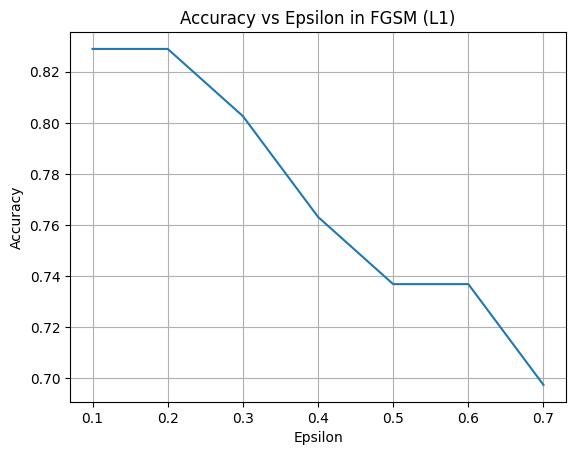

In [ ]:
norm_values = [1] 
eps_values = [0.1, 0.2, 0.3,0.4,0.5,0.6,0.7] 
eps_size_values = [1, 2, 3] 

results = []

for eps in eps_values:
    for eps_size in eps_size_values:
        for norm in norm_values:
            # Create the FGSM attack
            attack = FastGradientMethod(classifier, eps=eps, eps_step=eps_size, norm=norm)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (e.g., accuracy) and store the results
            accuracy = np.sum(y_test_adv_pred == y_test) / len(y_test)
            results.append((eps, eps_size, norm, accuracy))

# Step 5: Plot the results
eps_values = [result[0] for result in results]
accuracy_values = [result[3] for result in results]

plt.plot(eps_values, accuracy_values)
plt.xlabel('Epsilon')
plt.grid(True)
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon in FGSM (L1)')
plt.show()

### Norm: L-2

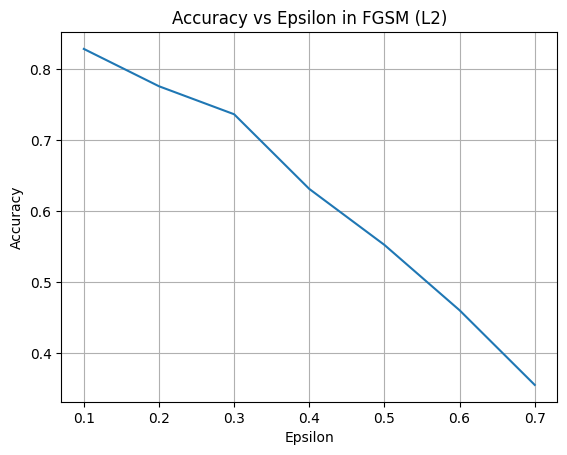

In [ ]:
norm_values = [2] 

results = []

for eps in eps_values:
    for eps_size in eps_size_values:
        for norm in norm_values:
            # Create the FGSM attack
            attack = FastGradientMethod(classifier, eps=eps, eps_step=eps_size, norm=norm)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (e.g., accuracy) and store the results
            accuracy = np.sum(y_test_adv_pred == y_test) / len(y_test)
            results.append((eps, eps_size, norm, accuracy))

# Step 5: Plot the results
eps_values = [result[0] for result in results]
accuracy_values = [result[3] for result in results]

plt.plot(eps_values, accuracy_values)
plt.xlabel('Epsilon')
plt.grid(True)
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epsilon in FGSM (L2)')
plt.show()

### Recall Plot: Norm: L-infinity

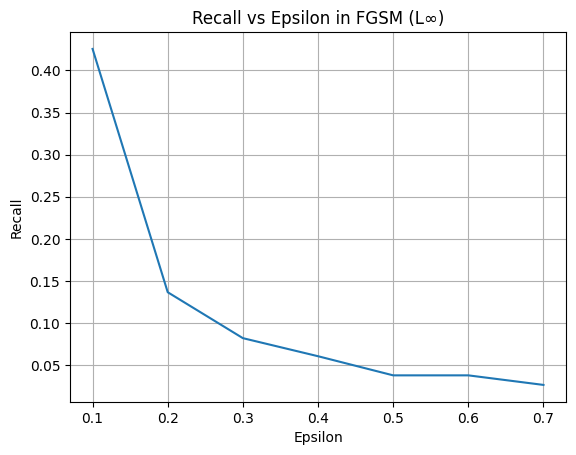

In [ ]:
results = []
norm_values = [np.inf]
for eps in eps_values:
    for eps_size in eps_size_values:
        for norm in norm_values:
            # Create the FGSM attack
            attack = FastGradientMethod(classifier, eps=eps, eps_step=eps_size, norm=norm)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (recall) and store the results
            recall = recall_score(y_test, y_test_adv_pred, average='macro')  # Calculate recall
            results.append((eps, eps_size, norm, recall))

# Step 5: Plot the results
eps_values = [result[0] for result in results]
recall_values = [result[3] for result in results]

plt.plot(eps_values, recall_values)
plt.xlabel('Epsilon')
plt.grid(True)
plt.ylabel('Recall')
plt.title('Recall vs Epsilon in FGSM (L∞)')
plt.show()

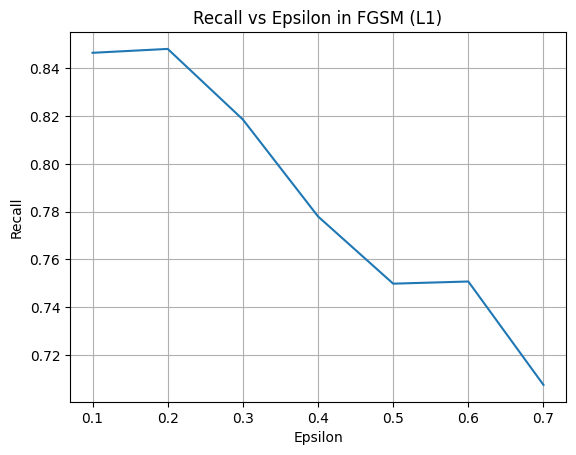

In [ ]:
results = []
norm_values = [1]
for eps in eps_values:
    for eps_size in eps_size_values:
        for norm in norm_values:
            # Create the FGSM attack
            attack = FastGradientMethod(classifier, eps=eps, eps_step=eps_size, norm=norm)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (recall) and store the results
            recall = recall_score(y_test, y_test_adv_pred, average='macro')  # Calculate recall
            results.append((eps, eps_size, norm, recall))

# Step 5: Plot the results
eps_values = [result[0] for result in results]
recall_values = [result[3] for result in results]

plt.plot(eps_values, recall_values)
plt.xlabel('Epsilon')
plt.grid(True)
plt.ylabel('Recall')
plt.title('Recall vs Epsilon in FGSM (L1)')
plt.show()

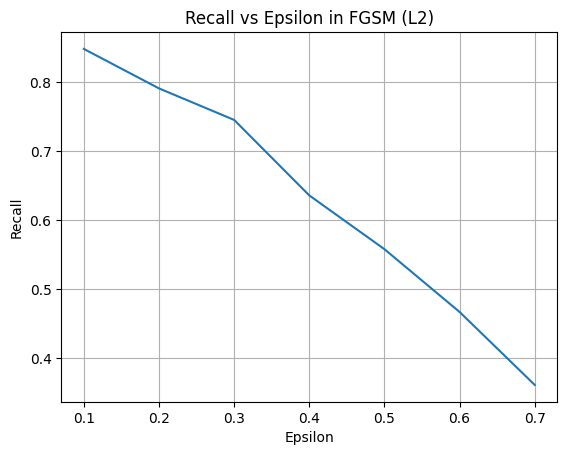

In [ ]:
results = []
norm_values = [2]
for eps in eps_values:
    for eps_size in eps_size_values:
        for norm in norm_values:
            # Create the FGSM attack
            attack = FastGradientMethod(classifier, eps=eps, eps_step=eps_size, norm=norm)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (recall) and store the results
            recall = recall_score(y_test, y_test_adv_pred, average='macro')  # Calculate recall
            results.append((eps, eps_size, norm, recall))

# Step 5: Plot the results
eps_values = [result[0] for result in results]
recall_values = [result[3] for result in results]

plt.plot(eps_values, recall_values)
plt.xlabel('Epsilon')
plt.grid(True)
plt.ylabel('Recall')
plt.title('Recall vs Epsilon in FGSM (L2)')
plt.show()

xaComparing plots of accuracy and recall against epsilon values provides insights into the trade-off between overall performance and the ability of the model to correctly identify positive instances.

Accuracy Plot: The accuracy plot shows how the overall performance of the model changes with different epsilon values. A higher accuracy indicates that the model is making correct predictions more often. However, accuracy alone may not fully represent the model's effectiveness, especially in scenarios with imbalanced classes or when false positives and false negatives have different costs.
Recall Plot: The recall plot, on the other hand, specifically focuses on the model's ability to correctly identify positive instances. A higher recall indicates that the model is better at capturing all positive instances, minimizing false negatives. This is particularly important in applications where missing positive instances (false negatives) is more critical than falsely identifying negative instances (false positives), such as medical diagnosis or anomaly detection.
By comparing these two plots, you can make the following inferences:

The trade-off between Accuracy and Recall: As epsilon values increase, the model's accuracy may decrease while recall increases. This trade-off suggests that as you prioritize the model's ability to capture positive instances (recall) by perturbing the input data more aggressively, you may sacrifice overall accuracy.


Impact of Attack Strength: Higher epsilon values or larger epsilon step sizes in FGSM attacks tend to result in more significant perturbations to the input data, which may lead to a decrease in accuracy but an increase in recall. This indicates that stronger attacks can make the model more sensitive to adversarial examples, potentially improving its ability to detect positive instances.


Model Robustness Assessment: Analyzing both accuracy and recall plots helps in assessing the robustness of the model against adversarial attacks. A model that maintains high accuracy and recall across different epsilon values is more robust against adversarial perturbations.
In summary, while accuracy provides a measure of overall performance, recall gives insights into the model's ability to correctly identify positive instances. Comparing plots of accuracy and recall against epsilon values helps in understanding the impact of adversarial attacks on model performance and assessing its robustness.

# Boundary Attack/ Decision Based Attack

Hyperparameters:

1epsilon (float) – Initial step size for the step towards the target.

step_adapt (float) – Factor by which the step sizes are multiplied or divided, must be in the range (0, 1).

max_iter (int) – Maximum number of iterations.

verbose (bool) – Show progress bars.

In [ ]:
# Initialize the Boundary Attack
attack = BoundaryAttack(estimator=classifier, targeted=False, max_iter=10, verbose=True)

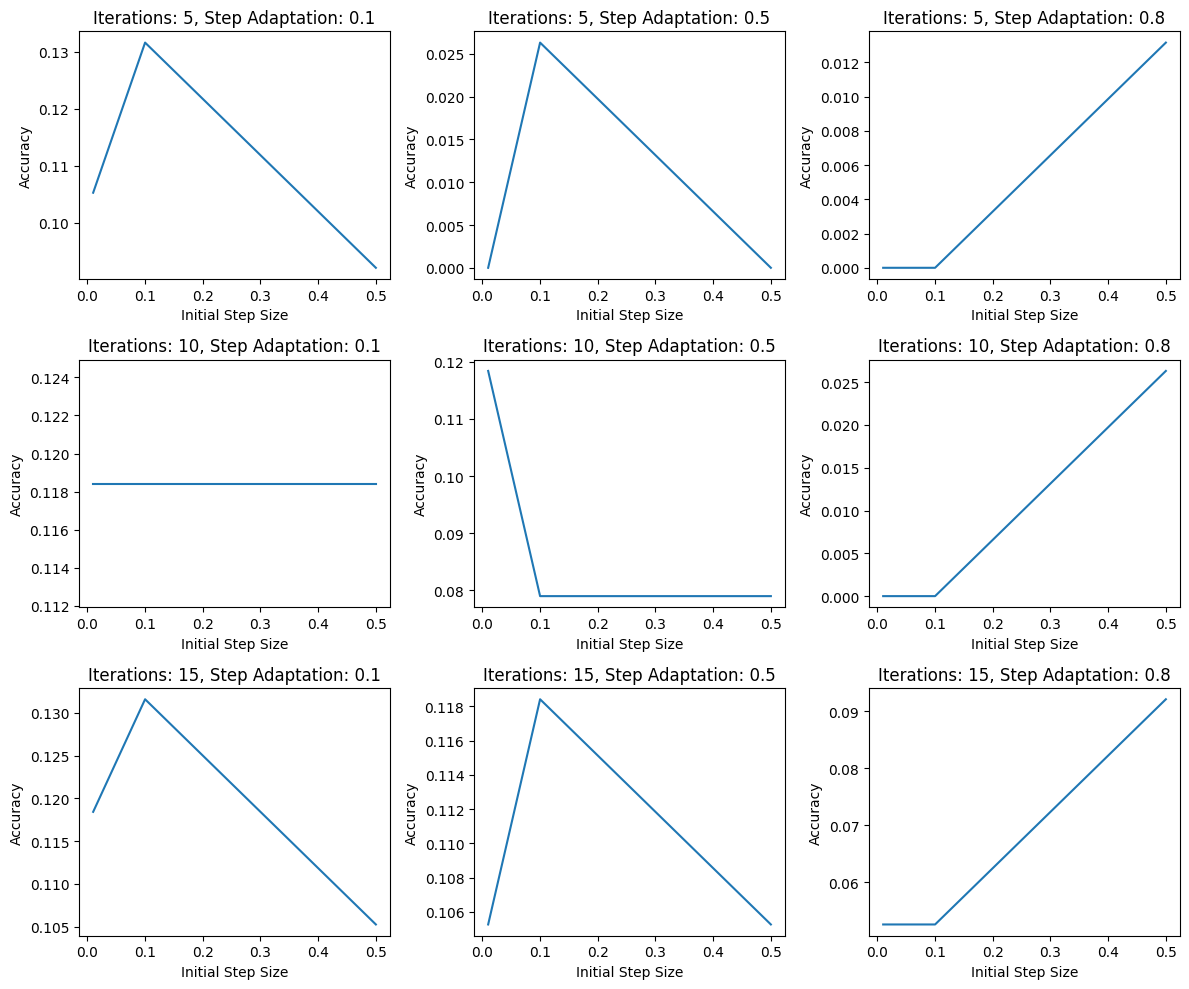

In [ ]:
attack_iterations = [5,10,15]  # Example iterations for the attack
step_adaptation = [0.1, 0.5, 0.8]  # Example step size adaptation
initial_step_size = [0.01, 0.1, 0.5]  # Example initial step size

results = []

for iterations in attack_iterations:
    for adaptation in step_adaptation:
        for step_size in initial_step_size:
            # Create the boundary attack
            attack = BoundaryAttack(classifier, targeted=False, max_iter=iterations, step_adapt=adaptation,
                                    sample_size=10, verbose=False)
            
            # Generate adversarial examples
            x_test_adv = attack.generate(X_test.to_numpy())  # Assuming x_test contains your test data
            
            # Step 4: Evaluate the perturbed examples
            y_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
            
            # Evaluate performance metrics (e.g., accuracy) and store the results
            accuracy = np.sum(y_test_adv_pred == y_test) / len(y_test)
            results.append((iterations, adaptation, step_size, accuracy))

# Step 5: Plot the results
accuracy_values = [result[3] for result in results]

# Reshape accuracy_values to match the grid of hyperparameters
accuracy_values = np.array(accuracy_values).reshape(len(attack_iterations), len(step_adaptation), len(initial_step_size))

# Plot the accuracy for each hyperparameter combination
fig, axes = plt.subplots(len(attack_iterations), len(step_adaptation), figsize=(12, 10))
for i, iterations in enumerate(attack_iterations):
    for j, adaptation in enumerate(step_adaptation):
        axes[i, j].plot(initial_step_size, accuracy_values[i, j, :])
        axes[i, j].set_xlabel('Initial Step Size')
        axes[i, j].set_ylabel('Accuracy')
        axes[i, j].set_title(f'Iterations: {iterations}, Step Adaptation: {adaptation}')
plt.tight_layout()
plt.show()

## Contour Plot regarding Boundary Attack

/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/utils/deprecation.py:103: FutureWarning: Attribute `n_features_` was deprecated in version 1.0 and will be removed in 1.2. Use `n_features_in_` instead.
  warnings.warn(msg, category=FutureWarning)
Before Attack - Accuracy: 0.88
Before Attack - Recall: 0.88
Before Attack - Precision: 0.91
Before Attack - F1 Score: 0.88
Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 227.46it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 212.46it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 290.55it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 320.23it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 245.90it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 242.78it/s]

Boundary attack: 100%|██████████| 10/10 [00:00<00:00, 18.83it/s]


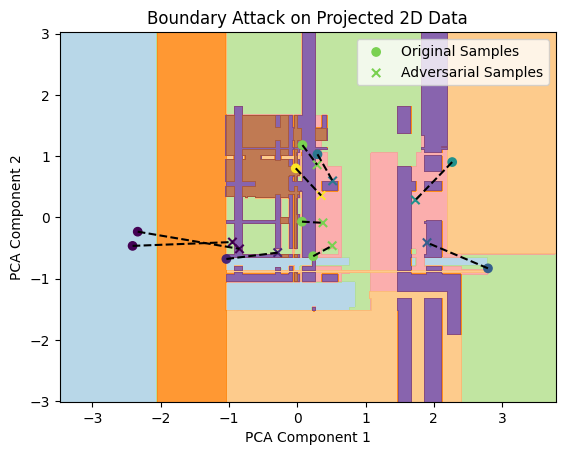

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from art.attacks.evasion import BoundaryAttack
from art.estimators.classification import SklearnClassifier
import matplotlib.pyplot as plt

# Load the dataset
file_path = './Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

# Preprocess the data
le = LabelEncoder()
data['prognosis'] = le.fit_transform(data['prognosis'])
X = data.drop(['prognosis'], axis=1).values
y = data['prognosis'].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train, y_train)

# Predict and evaluate before attack
y_pred = gb_clf.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred, average='weighted')
precision_before = precision_score(y_test, y_pred, average='weighted')
f1_before = f1_score(y_test, y_pred, average='weighted')

print(f"Before Attack - Accuracy: {accuracy_before:.2f}")
print(f"Before Attack - Recall: {recall_before:.2f}")
print(f"Before Attack - Precision: {precision_before:.2f}")
print(f"Before Attack - F1 Score: {f1_before:.2f}")

# Wrap the model with ART classifier
classifier = SklearnClassifier(model=gb_clf)

# Select a subset of test samples for the attack
num_samples = 10  # Number of samples to attack
X_attack = X_test[:num_samples]
y_attack = y_test[:num_samples]

# Perform Boundary Attack
attack = BoundaryAttack(estimator=classifier, targeted=False,max_iter=10)
X_attack_adv = attack.generate(x=X_attack)

# Project high-dimensional data to 2D using PCA
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test)
X_attack_2d = pca.transform(X_attack)
X_attack_adv_2d = pca.transform(X_attack_adv)

# Train a classifier on 2D projected data
gb_clf_2d = GradientBoostingClassifier()
gb_clf_2d.fit(X_test_2d, y_test)

# Create a meshgrid for plotting decision boundary
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Plot the decision boundary using contour plot
Z = gb_clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

# Plot original and adversarial samples
plt.scatter(X_attack_2d[:, 0], X_attack_2d[:, 1], c=y_attack, marker='o', label='Original Samples')
plt.scatter(X_attack_adv_2d[:, 0], X_attack_adv_2d[:, 1], c=y_attack, marker='x', label='Adversarial Samples')

# Optional: Plot the connections between original and adversarial samples
for i in range(len(X_attack)):
    plt.plot([X_attack_2d[i, 0], X_attack_adv_2d[i, 0]], [X_attack_2d[i, 1], X_attack_adv_2d[i, 1]], 'k--')

plt.legend()
plt.title("Boundary Attack on Projected 2D Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [ ]:
X_test[0],X_attack_adv[0]

array([0.8752164 , 0.76082337, 0.04651626, 0.67736125, 0.93565917,
       0.31397524, 0.36753902, 1.        , 0.960591  , 0.4377694 ,
       0.65293163, 0.7342545 , 0.40575483, 1.        , 0.22805741,
       0.8461719 , 0.6420371 , 0.        , 0.5217788 , 0.2585087 ,
       0.74438906, 0.6762706 , 0.9674429 , 0.83463705, 0.80676454,
       0.69133794, 0.77007985, 0.7029589 , 0.70738345, 0.96741974,
       0.6577279 , 0.5279111 , 1.        , 0.40871185, 0.11830093,
       0.15446107, 0.6619593 , 0.6709083 , 1.        , 0.8026476 ,
       0.5451218 , 0.        , 0.7826895 , 0.71643806, 0.27848333,
       0.8679665 , 0.33046672, 0.18610272, 0.56565857, 0.898497  ,
       0.57668453, 0.8165512 , 0.64029384, 0.9345235 , 0.07265193,
       0.31714195, 0.2634299 , 0.6841348 , 0.64656925, 0.8394676 ,
       0.73495454, 0.6596802 , 0.9726591 , 0.46529377], dtype=float32)

/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/utils/deprecation.py:103: FutureWarning: Attribute `n_features_` was deprecated in version 1.0 and will be removed in 1.2. Use `n_features_in_` instead.
  warnings.warn(msg, category=FutureWarning)
Before Attack - Accuracy: 0.90
Before Attack - Recall: 0.90
Before Attack - Precision: 0.91
Before Attack - F1 Score: 0.90
Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 264.37it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 230.83it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 321.17it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 157.51it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 188.76it/s]

Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 203.57it/s]

Boundary attack: 100%|██████████| 10/10 [00:00<00:00, 18.88it/s]
/tmp/ipykernel_81/608094846.py:87: UserWarning: You passed a edgecolor/e

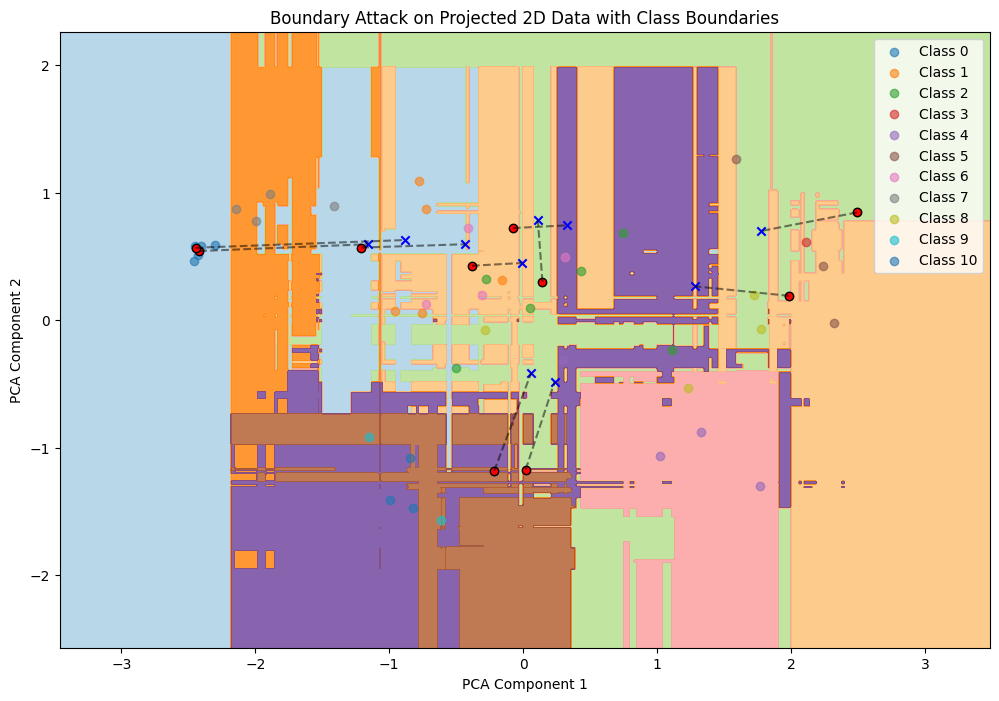

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from art.attacks.evasion import BoundaryAttack
from art.estimators.classification import SklearnClassifier
import matplotlib.pyplot as plt

# Load the dataset
file_path = './Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

# Preprocess the data
le = LabelEncoder()
data['prognosis'] = le.fit_transform(data['prognosis'])
X = data.drop(['prognosis'], axis=1).values
y = data['prognosis'].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train, y_train)

# Predict and evaluate before attack
y_pred = gb_clf.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred, average='weighted')
precision_before = precision_score(y_test, y_pred, average='weighted')
f1_before = f1_score(y_test, y_pred, average='weighted')

print(f"Before Attack - Accuracy: {accuracy_before:.2f}")
print(f"Before Attack - Recall: {recall_before:.2f}")
print(f"Before Attack - Precision: {precision_before:.2f}")
print(f"Before Attack - F1 Score: {f1_before:.2f}")

# Wrap the model with ART classifier
classifier = SklearnClassifier(model=gb_clf)

# Select a subset of test samples for the attack
num_samples = 10  # Number of samples to attack
X_attack = X_test[:num_samples]
y_attack = y_test[:num_samples]

# Perform Boundary Attack
attack = BoundaryAttack(estimator=classifier, targeted=False,max_iter=10)
X_attack_adv = attack.generate(x=X_attack)

# Project high-dimensional data to 2D using PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)
X_attack_2d = pca.transform(X_attack)
X_attack_adv_2d = pca.transform(X_attack_adv)

# Train a classifier on 2D projected data
gb_clf_2d = GradientBoostingClassifier()
gb_clf_2d.fit(X_train_2d, y_train)

# Create a meshgrid for plotting decision boundary
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Plot the decision boundary using contour plot
Z = gb_clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

# Plot original and adversarial samples
for class_value in np.unique(y):
    idx = np.where(y_test == class_value)
    plt.scatter(X_test_2d[idx, 0], X_test_2d[idx, 1], label=f'Class {class_value}', alpha=0.6)

# Plot original and adversarial samples with connections
for i in range(len(X_attack)):
    plt.plot([X_attack_2d[i, 0], X_attack_adv_2d[i, 0]], 
             [X_attack_2d[i, 1], X_attack_adv_2d[i, 1]], 
             'k--', alpha=0.5)
    plt.scatter(X_attack_2d[i, 0], X_attack_2d[i, 1], c='red', marker='o', edgecolor='k')
    plt.scatter(X_attack_adv_2d[i, 0], X_attack_adv_2d[i, 1], c='blue', marker='x', edgecolor='k')

plt.legend()
plt.title("Boundary Attack on Projected 2D Data with Class Boundaries")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


/shared-libs/python3.9/py/lib/python3.9/site-packages/sklearn/utils/deprecation.py:103: FutureWarning: Attribute `n_features_` was deprecated in version 1.0 and will be removed in 1.2. Use `n_features_in_` instead.
  warnings.warn(msg, category=FutureWarning)
Before Attack - Accuracy: 0.90
Before Attack - Recall: 0.90
Before Attack - Precision: 0.91
Before Attack - F1 Score: 0.90
Boundary attack - iterations: 100%|██████████| 10/10 [00:00<00:00, 375.18it/s]

Boundary attack: 100%|██████████| 2/2 [00:00<00:00, 27.28it/s]
/tmp/ipykernel_81/2525703111.py:87: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_attack_adv_2d[i, 0], X_attack_adv_2d[i, 1], c='blue', marker='x', edgecolor='k')


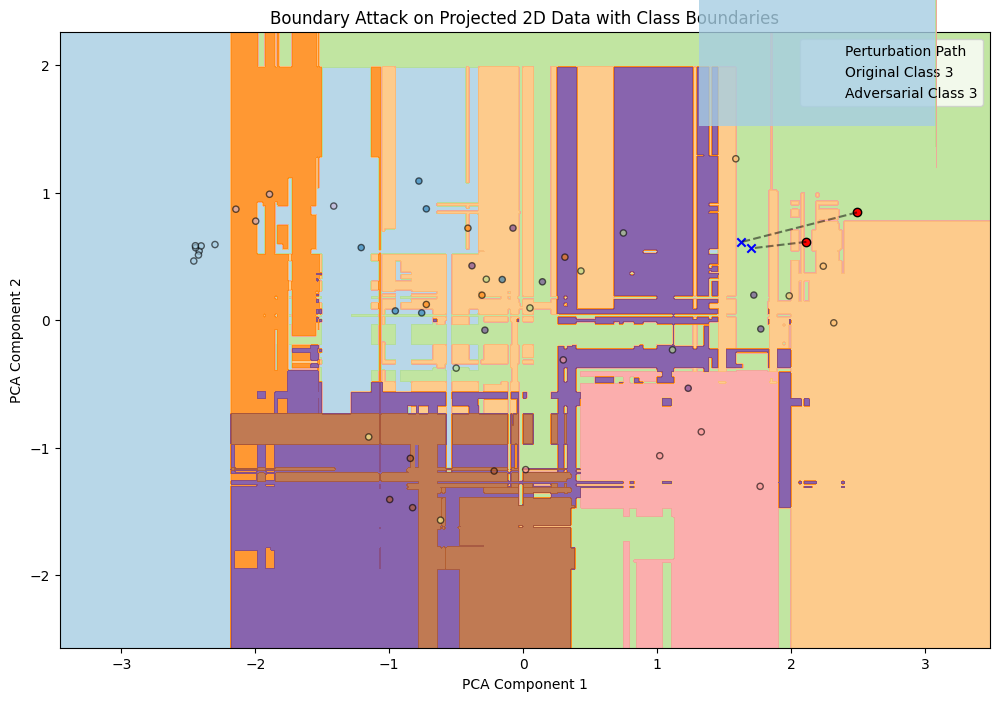

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from art.attacks.evasion import BoundaryAttack
from art.estimators.classification import SklearnClassifier
import matplotlib.pyplot as plt

# Load the dataset
file_path = './Downloaded/vbd-richard-bernat/trainn.csv'
data = pd.read_csv(file_path)

# Preprocess the data
le = LabelEncoder()
data['prognosis'] = le.fit_transform(data['prognosis'])
X = data.drop(['prognosis'], axis=1).values
y = data['prognosis'].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train, y_train)

# Predict and evaluate before attack
y_pred = gb_clf.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred, average='weighted')
precision_before = precision_score(y_test, y_pred, average='weighted')
f1_before = f1_score(y_test, y_pred, average='weighted')

print(f"Before Attack - Accuracy: {accuracy_before:.2f}")
print(f"Before Attack - Recall: {recall_before:.2f}")
print(f"Before Attack - Precision: {precision_before:.2f}")
print(f"Before Attack - F1 Score: {f1_before:.2f}")

# Wrap the model with ART classifier
classifier = SklearnClassifier(model=gb_clf)

# Select 10 data points from X_test labeled as class 3
target_class = 3
class_indices = np.where(y_test == target_class)[0]
selected_indices = class_indices[:10]  # Take the first 10 samples of class 3
X_attack = X_test[selected_indices]
y_attack = y_test[selected_indices]

# Perform Boundary Attack
attack = BoundaryAttack(estimator=classifier, targeted=False,max_iter=10)
X_attack_adv = attack.generate(x=X_attack)

# Project high-dimensional data to 2D using PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)
X_attack_2d = pca.transform(X_attack)
X_attack_adv_2d = pca.transform(X_attack_adv)

# Train a classifier on 2D projected data
gb_clf_2d = GradientBoostingClassifier()
gb_clf_2d.fit(X_train_2d, y_train)

# Create a meshgrid for plotting decision boundary
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Plot the decision boundary using contour plot
Z = gb_clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

# Plot original and adversarial samples
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap=plt.cm.Paired, edgecolor='k', s=20, alpha=0.6)

# Plot original and adversarial samples with connections for class 3
for i in range(len(X_attack)):
    plt.plot([X_attack_2d[i, 0], X_attack_adv_2d[i, 0]], 
             [X_attack_2d[i, 1], X_attack_adv_2d[i, 1]], 
             'k--', alpha=0.5)
    plt.scatter(X_attack_2d[i, 0], X_attack_2d[i, 1], c='red', marker='o', edgecolor='k')
    plt.scatter(X_attack_adv_2d[i, 0], X_attack_adv_2d[i, 1], c='blue', marker='x', edgecolor='k')

plt.legend(['Perturbation Path', 'Original Class 3', 'Adversarial Class 3'])
plt.title("Boundary Attack on Projected 2D Data with Class Boundaries")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


TODO: Make sure that the contour plots of the FGSM attack is to be added in this section as well (concerning the documentation). 

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82fc1969-7ff0-4344-a3e7-65ed95a291e5' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>